In [ ]:
from nocode_robot_programming.state_decision.utils import kill_other_ipykernels
kill_other_ipykernels(force=True)
import trajectory_data
import matplotlib.pyplot as plt
from nocode_robot_programming.state_decision.dataloader import TrajectoryDataset
from nocode_robot_programming.state_decision.dino_model import DINOStateDecider
from nocode_robot_programming.state_decision.SIFT_model import StateDeciderSIFT
from nocode_robot_programming.state_decision.AEGP_model import AEGP
from nocode_robot_programming.state_decision.state_decider import StateDeciderBase
from gesture_detector.utils import pretty_confusion_matrix
import torch
import numpy as np
import matplotlib.pyplot as plt

from trajectory_data.skill_visualizer import play_video
from nocode_robot_programming.state_decision.utils import add_tag
from nocode_robot_programming.state_decision.dataloader import ImageDatasetView, saved_img_processing

seed = 50
np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

from nocode_robot_programming.state_decision.dataset_d1 import d1_peg_pick, dupl
datafileloader = TrajectoryDataset(trajectory_data.package_path)
datasets = d1_peg_pick(datafileloader)

24648 /home/steve/miniconda3/envs/gesturenlu/bin/python -m ipykernel_launcher --f=/run/user/1000/jupyter/runtime/kernel-v34574ff0202c7b55af4ac701d42f3bbf140586db5.json
Killed 24648: /home/steve/miniconda3/envs/gesturenlu/bin/python -m ipykernel_launcher --f=/run/user/1000/jupyter/runtime/kernel-v34574ff0202c7b55af4ac701d42f3bbf140586db5.json


# Load trajectory loader dataset

- `TrajectoryDataset` loads trajectory files
- `TrajectoryDataset.tasks` task structure
- 

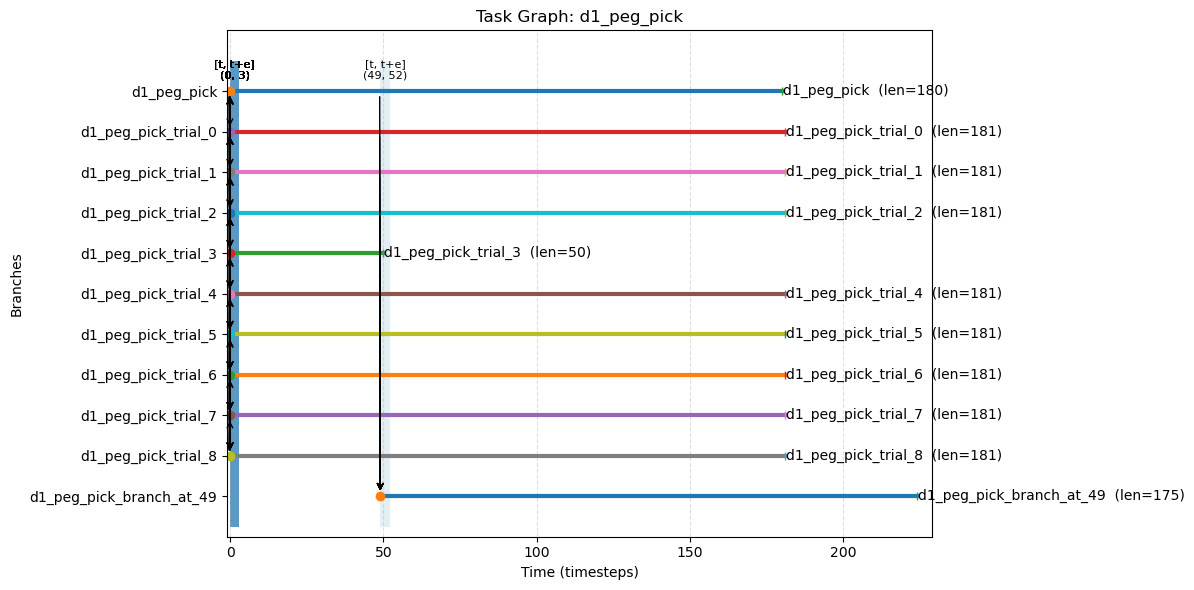

In [ ]:
datafileloader.get_task_graph_structure("d1_peg_pick")

In [9]:
# decider = DINOStateDecider()
# decider = StateDeciderSIFT()
decider = AEGP()
# decider = StateDeciderBase()

# Classification train/predict pipeline test

In [ ]:
d_train, d_test, d_text = datasets[0]
decider.train(d_train.X, d_train.y_int, d_train.y_cls)

Epoch [15/50], Trainloss: 0.794, ValLoss: 0.00384:  32%|███▏      | 16/50 [00:05<00:12,  2.75it/s] 


KeyboardInterrupt: 

In [ ]:
decider.videoembedder.model.eval()
image = d.X[0]
with torch.no_grad():
    latent = decider.videoembedder.model.encoder(image.unsqueeze(0).unsqueeze(0)) # (1, 1, width, height), 4D
    out = decider.videoembedder.model.decoder(latent)
plt.imshow(out.squeeze().detach().cpu())

In [ ]:
y_pred = predict(decider, d.X)

In [ ]:

pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls),len(decider.y_cls)))

# Dataset setup from demonstrations

- There are available tasks

In [ ]:
print(dataset)

I select the `d1_peg_pick`

In [ ]:
task_name = "d1_peg_pick"

- There are skill variations (demonstrations) for this task

In [ ]:
dataset.tasks[task_name]['names']

- I need to label each trial with a `tag`

# Dataset Option 1: Use just original and recovery motion

In [ ]:
def option1_discard_trials(dataset, task_name):
    return [s for s in dataset.tasks[task_name]['names'] if "_trial_" not in s]

In [ ]:
d = dataset.get_image_dataset(option1_discard_trials(dataset, task_name))

In [ ]:

for decider in [
    StateDeciderBase(),
    DINOStateDecider(),
    StateDeciderSIFT(),
    AEGP(),
    ]:
    decider.train(d.X, d.y_int, d.y_cls)
    y_pred = predict(decider, d.X)
    pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)

In [ ]:

for task_name in dataset.tasks.keys():
    d = dataset.get_image_dataset(option1_discard_trials(dataset, task_name))
    for decider in [
            DINOStateDecider(),
            StateDeciderSIFT(),
            AEGP(),
        ]:
        decider.train(d.X, d.y_int, d.y_cls)
        y_pred = predict(decider, d.X)
        
        pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)

# Dataset d1 evaluation

- Keep initial settings, do not finetune the methods.
- Problems of this evaluation: Just training dataset, not splitting into train/test -> next steps, this is just proof if it can learn, not generalize
- There are no anomalies in the dataset while the models can trigger it.
- What is estimated? The original demonstration has a peg at location A, recovery has at location B. In the image, the peg is not visible at location A, estimator switches to recovery motion.

task name                       | modality | DINO | SIFT | AE-GP        
------------------------------- | -------- | ---- | ---- | ----
d1_peg_pick                     | kine     | 85%  | 89%  | 100% 
d2_peg_pick                     | joystick | 80.1%| 85.8%| 100%
d3_peg_pick                     | gestures | 82.2%| 90.0%| 99.5%
d1_probe                        | kine     | 79.8%| 70.3%| 88.8%
d2_probe                        | joystick | 75.4%| 79.9%| 99.6%
d3_probe                        | gestures | 87.5%| 90.5%| 99.89%

Total: 2 tasks, 12 demonstrations, 3 modalities

Download link (need CIIRC permission) at: https://drive.google.com/drive/folders/1WAZegaslnaMCgeS_O-wCrwGM7oJdXuNA?usp=sharing

### Next steps:

- [x] tag the skill variations
- [x] train/test dataset subsets
- [/] Retrain
- [ ] Finetune & work on each methods
- [ ] Trigger anomaly (make a dataset) from the unseen data and evaluate the models

# Dataset d1 option 2 (d1o2)

## Tagging process

1. See the files
2. Be able to play it
3. Tag it with function

In [ ]:
dataset.tasks.keys()

In [ ]:
task_name = "d3_probe"

In [ ]:
dataset.tasks[task_name]['names']

In [ ]:
video_name = 'd3_probe_trial_2'
video_name

In [ ]:
play_video(dataset[video_name]['img'].squeeze().numpy() * 255, scale=3.0)

In [ ]:
add_tag(video_name, "d3_probe_branch_at_118")

# Split the train and test

## Now see the tagging

In [ ]:
def option2_trials_are_test_data(dataset, task_name):
    # def get_image_dataset(self, task_name: str) -> ImageDatasetView:
    file_names = dataset.tasks[task_name]['names']
    assert len(file_names) > 0
    X = torch.tensor([])
    Xt = torch.tensor([])
    y_int = torch.tensor([], dtype=torch.int)
    y_names = []

    tags = []
    for file in file_names:
        tags.append(dataset[file]['tag'])
    tags = list(set(tags))

    for file in file_names:
        try:
            branch_timestep = int(file.split("_")[-1])
        except ValueError:
            branch_timestep = 0
        idx = dataset.files.index(f"{dataset.dir}/{file}.npz")
        nsamples = len(dataset[idx]['img'])
        
        tag = dataset[file]['tag']
        i = tags.index(tag)

        # X.shape = (samples, width, height)
        X = torch.hstack([X, saved_img_processing(dataset[idx]['img'].squeeze())])
        
        # Xt.shape 
        xt_list = torch.tensor(list(range(branch_timestep,branch_timestep+nsamples)))
        Xt = torch.concatenate([Xt, xt_list])
        
        y_int = torch.concatenate([y_int, torch.tensor([i] * nsamples)])
        y_names.extend([tag] * nsamples)
    return ImageDatasetView(X = X.squeeze(), Xt = Xt, y_int = y_int, y_names = y_names, y_cls = tags)

# Evaluate

In [ ]:
for task_name in dataset.tasks.keys():
    d_train = option2_trials_are_test_data(dataset, task_name)
    d_test = option2_trials_are_test_data(dataset, task_name)
    for decider in [
            # DINOStateDecider(),
            # StateDeciderSIFT(),
            AEGP(),
        ]:
        decider.train(d_train.X, d_train.y_int, d_train.y_cls)
        y_pred = predict(decider, d_test.X)
        
        pretty_confusion_matrix.pp_matrix_from_string_data(d_test.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)

In [ ]:
dino = DINOStateDecider()
for task_name in dataset.tasks.keys():
    d_train = option2_trials_are_test_data(dataset, task_name)
    d_test = option2_trials_are_test_data(dataset, task_name)
    for decider in [
            dino,
        ]:
        decider.train(d_train.X, d_train.y_int, d_train.y_cls)
        y_pred = predict(decider, d_test.X)
        
        pretty_confusion_matrix.pp_matrix_from_string_data(d_test.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)